In [1]:
!nvidia-smi

Sun Mar 22 16:22:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import keras as kr
from keras import layers
import seaborn as sb
import sklearn
import tensorflow as tf
import random as rnd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

sklearn.set_config(transform_output="pandas")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/My Drive/waste-clasifier/

/content/drive/My Drive/waste-clasifier


In [5]:
classes = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

In [108]:
train_csv=pd.read_csv("train/_classes.csv")
train_df=pd.DataFrame(train_csv)
test_csv=pd.read_csv("test/_classes.csv")
test_df=pd.DataFrame(test_csv)
valid_csv=pd.read_csv("valid/_classes.csv")
valid_df=pd.DataFrame(valid_csv)

y_train = train_df[classes].values
y_val = valid_df[classes].values
y_test = test_df[classes].values
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1767 entries, 0 to 1766
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   filename   1767 non-null   object
 1   cardboard  1767 non-null   int64 
 2   glass      1767 non-null   int64 
 3   metal      1767 non-null   int64 
 4   paper      1767 non-null   int64 
 5   plastic    1767 non-null   int64 
 6   trash      1767 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 96.8+ KB


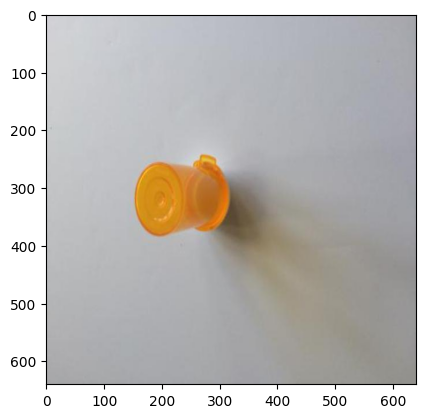

In [7]:
random_idx = rnd.randint(0, len(train_df) - 1)
img_path = os.path.join("train", train_df["filename"][random_idx])
img = mpimg.imread(img_path)
plt.imshow(img)
plt.show()

In [8]:
vis_df=pd.DataFrame({
    "train":train_df[classes].sum(),
    "test":test_df[classes].sum(),
    "valid":valid_df[classes].sum()
})
vis_df

,train,test,valid
cardboard,275,44,84
glass,352,47,102
metal,284,40,85
paper,423,64,107
plastic,340,44,96
trash,93,14,30


<Axes: xlabel='category', ylabel='count'>

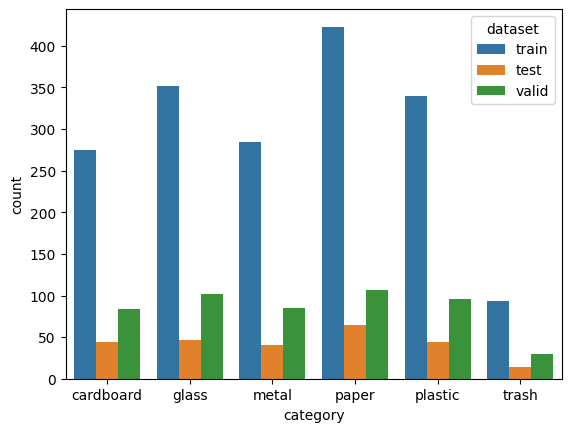

In [9]:
df_plot = vis_df.reset_index().rename(columns={'index': 'category'})
df_melted = df_plot.melt(id_vars='category', var_name='dataset', value_name='count')
sb.barplot(data=df_melted, x='category', y='count', hue='dataset')

In [ ]:
datagen = ImageDataGenerator(rescale=1./255)
image_size=256
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory="train/",
    x_col=train_df.columns[0],
    y_col=classes,
    target_size=(image_size, image_size),
    batch_size=32,
    class_mode="raw"
)

Found 1767 validated image filenames.


In [67]:
valid_generator = datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory="valid/",
    x_col=valid_df.columns[0],
    y_col=classes,
    target_size=(image_size, image_size),
    batch_size=32,
    class_mode="raw"
)

Found 504 validated image filenames.


In [68]:
test_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    directory="test/",
    x_col=train_df.columns[0],
    y_col=classes,
    target_size=(image_size, image_size),
    batch_size=32,
    class_mode="raw"
)

Found 253 validated image filenames.


In [91]:
from sklearn.utils.class_weight import compute_class_weight

one_hot_labels = train_df[classes].values 
print(one_hot_labels)

train_classes_int = np.argmax(one_hot_labels, axis=1)
print(train_classes_int)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes_int),
    y=train_classes_int
)

class_weights_dict = dict(enumerate([x for x in class_weights_array]))
print(sum(class_weights_dict))

print("Wyliczone wagi klas:", class_weights_dict)

[[0 0 0 1 0 0]
 [0 0 0 1 0 0]
 [0 0 0 1 0 0]
 ...
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]]
[3 3 3 ... 0 0 0]
15
Wyliczone wagi klas: {0: np.float64(1.0709090909090908), 1: np.float64(0.8366477272727273), 2: np.float64(1.0369718309859155), 3: np.float64(0.6962174940898345), 4: np.float64(0.8661764705882353), 5: np.float64(3.1666666666666665)}


In [ ]:
conv_dense=4
model=kr.Sequential(
    [
        layers.Input((image_size,image_size,3)),

        #layers.RandomRotation

        layers.Conv2D(conv_dense, 7, strides=1, activation="softplus", use_bias=True, padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),

        layers.Conv2D((2*conv_dense), 5, strides=1, activation="softplus", use_bias=True, padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),

        layers.Conv2D((3*conv_dense), 3, strides=1, activation="softplus", use_bias=True, padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),

        layers.Conv2D((4*conv_dense), 3, strides=1, activation="softplus", use_bias=True, padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),
        
        #layers.AveragePooling2D(pool_size=(2, 2), strides=None, padding="valid"),
        layers.Flatten(),
        
        layers.Dropout(0.5),

        #layers.Dense(100,activation="softplus"),
        layers.Dense(100,activation="tanh"),

        layers.Dropout(0.3),
        
        layers.Dense(6, activation="softmax")
    ]
)

model.build()
model.summary()
#kr.utils.plot_model(model, show_shapes=True)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_64 (Conv2D)              │ (None, 256, 256, 4)    │           592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 256, 256, 4)    │            16 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (None, 128, 128, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 128, 128, 8)    │           808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 128, 128, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_65 (MaxPooling2D) │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 64, 64, 12)     │           876 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 64, 64, 12)     │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_66 (MaxPooling2D) │ (None, 32, 32, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 32, 32, 16)     │         1,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_67          │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_67 (MaxPooling2D) │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 100)            │       409,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,486 (1.58 MB)

 Trainable params: 414,406 (1.58 MB)

 Non-trainable params: 80 (320.00 B)

In [45]:
model_load = kr.models.load_model(
    "sml_model50.keras"
    #custom_objects={"full_attention_block": full_attention_block
                    #,"loss":get_sparse_weighted_loss
                    #}
)

In [105]:
epochs = 50
Adam = kr.optimizers.Adam(learning_rate=0.001)
r_lr=kr.callbacks.ReduceLROnPlateau(patience=2, monitor="val_accuracy",factor=0.7)
e_s=kr.callbacks.EarlyStopping(patience=10, monitor="val_accuracy")
model.compile(optimizer=Adam,loss="categorical_crossentropy",metrics =['accuracy','recall','precision'])
model.fit(
    train_generator,
    epochs=epochs,
    callbacks=[r_lr,e_s],
    validation_data=valid_generator,
    class_weight=class_weights_dict
)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 293ms/step - accuracy: 0.3967 - loss: 1.6984 - precision: 0.4534 - recall: 0.2999 - val_accuracy: 0.2123 - val_loss: 2.5959 - val_precision: 0.2123 - val_recall: 0.2123 - learning_rate: 0.0010
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 201ms/step - accuracy: 0.5042 - loss: 1.3589 - precision: 0.5900 - recall: 0.3803 - val_accuracy: 0.3056 - val_loss: 2.5170 - val_precision: 0.3108 - val_recall: 0.2004 - learning_rate: 0.0010
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.5586 - loss: 1.1785 - precision: 0.6367 - recall: 0.4284 - val_accuracy: 0.4246 - val_loss: 1.4583 - val_precision: 0.7255 - val_recall: 0.2202 - learning_rate: 0.0010
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 191ms/step - accuracy: 0.5829 - loss: 1.1090 - precision: 0.6661 - recall: 0.4788 - val_accuracy: 0.1944 - val_loss: 2.5924 - val_precision: 0.1984 - val_recall: 0.1925 - learning_rate: 0.0010
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 197ms/step - accur

In [106]:
model.evaluate(test_generator)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 242ms/step - accuracy: 0.6482 - loss: 1.0186 - precision: 0.7182 - recall: 0.6245


[1.0185754299163818,
 0.6482213735580444,
 0.6245059370994568,
 0.7181817889213562]

In [ ]:
model.save('next3_model43.keras')

In [ ]:
"""
next3_model43 | accuracy: 0.6482 - loss: 1.0186 - precision: 0.7182 - recall: 0.6245
next2_model34 | accuracy: 0.6640 - loss: 1.0755 - precision: 0.7257 - recall: 0.6482
next_model38 | accuracy: 0.6719 - loss: 1.0829 - precision: 0.7124 - recall: 0.6364
thing_model38 | accuracy: 0.6561 - loss: 1.0464 - precision: 0.7182 - recall: 0.6245
gigant3_model42 | accuracy: 0.6719 - loss: 0.9546 - precision: 0.7212 - recall: 0.5929 - 256
gigant2_model38 | accuracy: 0.6087 - loss: 1.0791 - precision: 0.6837 - recall: 0.5296 - 256
gigant_model47 | accuracy: 0.6443 - loss: 0.9469 - precision: 0.7311 - recall: 0.6126 - 256
ballanced2_model47 | accuracy: 0.6522 - loss: 1.0356 - precision: 0.7436 - recall: 0.5731 - 256
ballanced_model34 | accuracy: 0.6561 - loss: 1.0261 - precision: 0.7346 - recall: 0.6126 - 128
overfitted_model23 | accuracy: 0.6245 - loss: 1.3682 - precision: 0.6565 - recall: 0.5968 - 128
mikro_model50 | accuracy: 0.6877 - loss: 0.9676 - precision: 0.7451 - recall: 0.6008 - 128
mikro_model67 | accuracy: 0.6759 - loss: 0.9928 - precision: 0.7299 - recall: 0.6087 - 128
good_model1 | accuracy: 0.2530 - loss: 2.6561 - precision: 0.2530 - recall: 0.2530 - 128
good_model2 | accuracy: 0.3439 - loss: 2.1603 - precision: 0.3798 - recall: 0.3123 - 128
bigger_good_model50 | accuracy: 0.6877 - loss: 0.9277 - precision: 0.7273 - recall: 0.6324 - 128
cnn_mini1 | accuracy: 0.2530 - loss: 1.7233 - precision: 0.0000e+00 - recall: 0.0000e+00 - 128
cnn_test1 | accuracy: 0.1779 - loss: 10.2570 - precision: 0.2003 - recall: 0.6008 - 128
cnn_test2 | accuracy: 0.1581 - loss: 6.6893 - precision: 0.2055 - recall: 0.4111 - 128
idk_model50 | accuracy: 0.5850 - loss: 1.1330 - precision: 0.7634 - recall: 0.3953 - 128
sml_model46 | accuracy: 0.6522 - loss: 0.9800 - precision: 0.7225 - recall: 0.5968 - 128
sml_model50 | accuracy: 0.6245 - loss: 1.0281 - precision: 0.7020 - recall: 0.5494 - 128






"""